In [1]:
import matplotlib.pyplot as plt

import numpy as np
import anndata as ad
import polars as pl
import sys

import src as scit

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mutant = ad.read_h5ad('private/data/clean_method/mutant.h5ad')
early = ad.read_h5ad('private/data/clean_method/early.h5ad')
late = ad.read_h5ad('private/data/clean_method/late.h5ad')

In [3]:
import pandas as pd
mutant.obs['identity'] = pd.Categorical('mutant_' + mutant.obs['batch'].to_numpy())
early.obs['identity'] = pd.Categorical('early_' + early.obs['batch'].to_numpy())
late.obs['identity'] = pd.Categorical('late_' + late.obs['batch'].to_numpy())

In [4]:
adata = ad.concat((mutant, early, late))
adata

AnnData object with n_obs × n_vars = 48542 × 25091
    obs: 'acet_total_counts', 'meth_total_counts', 'exclude', 'batch', 'timep', 'leiden', 'identity'
    obsm: 'X_acetylation', 'X_methylation', 'X_multi_spectral', 'X_umap'
    layers: 'acet', 'meth'

In [5]:
scit.tl.add_metadata(adata, ['meth', 'acet'], var_loc_metadata=False)
adata.var

Info: Added meth counts metadata
Info: Added acet counts metadata


,meth_total_counts,acet_total_counts
chr2L:0-5000,20,8
chr2L:10000-15000,355,741
chr2L:100000-105000,174,883
chr2L:10000000-10005000,320,1385
chr2L:10005000-10010000,210,1061
...,...,...
chrY:85000-90000,11,23
chrY:855000-860000,6,20
chrY:90000-95000,20,20
chrY:95000-100000,11,15


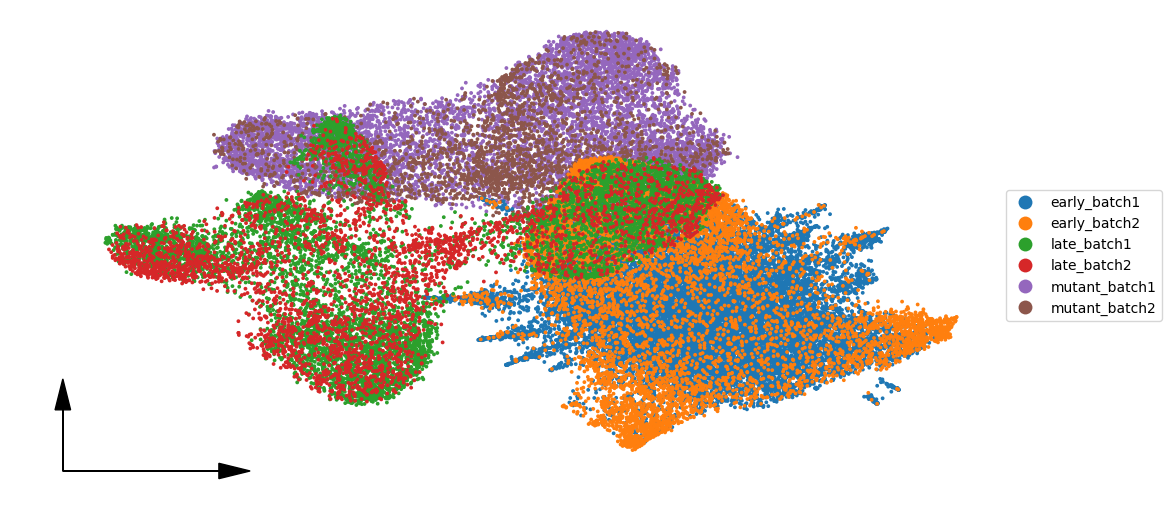

In [6]:
scit.pl.embedding2d(adata, 'X_umap', 'identity')

In [7]:
lc_meth = scit.tl.make_layer_config('meth', normalize_with_obs_counts=False)
lc_acet = scit.tl.make_layer_config('acet', normalize_with_obs_counts=False)


Info: Picked 20375 features


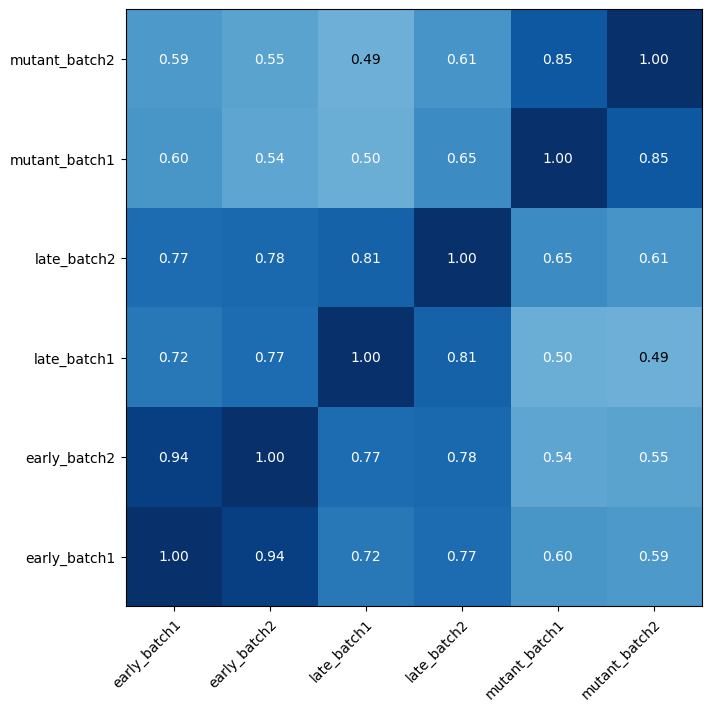

In [8]:
scit.tl.layer_pick_features(adata, lc_acet, filter_min=500)
data, labels = scit.tl.rep_correlation(
    adata,
    lc_acet, 
    'identity',
    use_cached_mask=True
)

scit.set_defaults(figsize=(7,7))
f=scit.pl.int.heatmap(
    data,
    labels,
    vminmax=(0,1),
    show_entries=True,
    square_matrix=True, show=False
)
f.savefig('private/newest/figures/corr_matrix_acet.png')

Info: Picked 16790 features


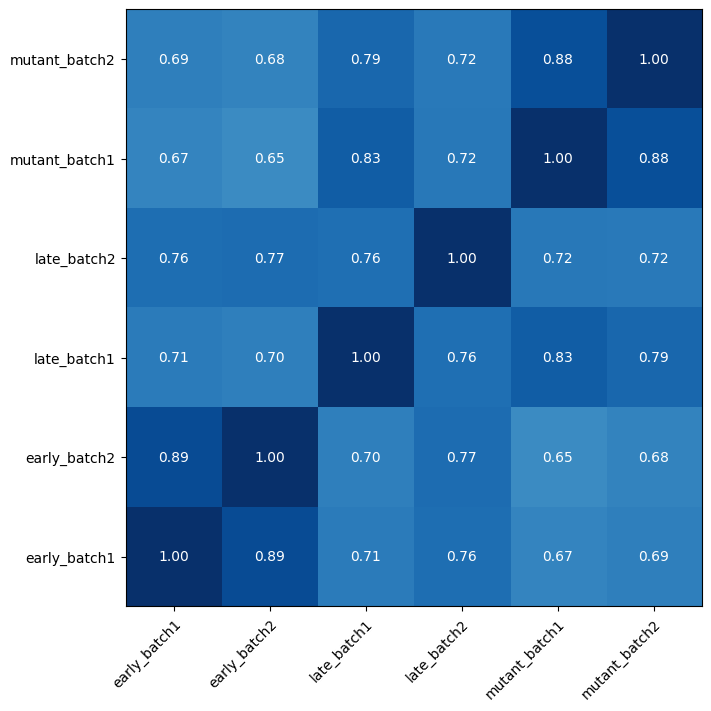

In [9]:
scit.tl.layer_pick_features(adata, lc_meth, filter_min=200)
data, labels = scit.tl.rep_correlation(
    adata,
    lc_meth, 
    'identity',
    use_cached_mask=True
)

scit.set_defaults(figsize=(7,7))
f=scit.pl.int.heatmap(
    data,
    labels,
    vminmax=(0,1),
    show_entries=True,
    square_matrix=True, show=False
)

f.savefig('private/newest/figures/corr_matrix_meth.png')

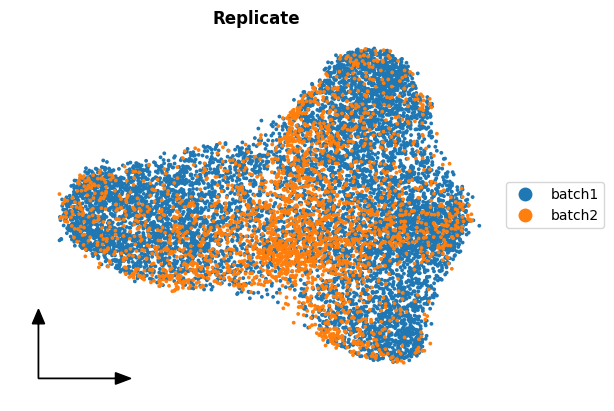

In [35]:
scit.set_defaults(figsize=(5,4))
scit.pl.embedding2d(mutant, 'X_umap', 'batch', title=f'Replicate', show=False).savefig('private/newest/screenshots/mutant_covariate.png',dpi=400)

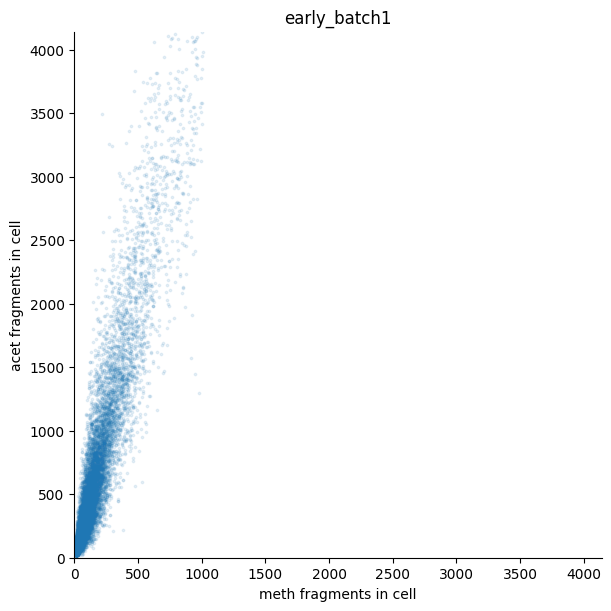

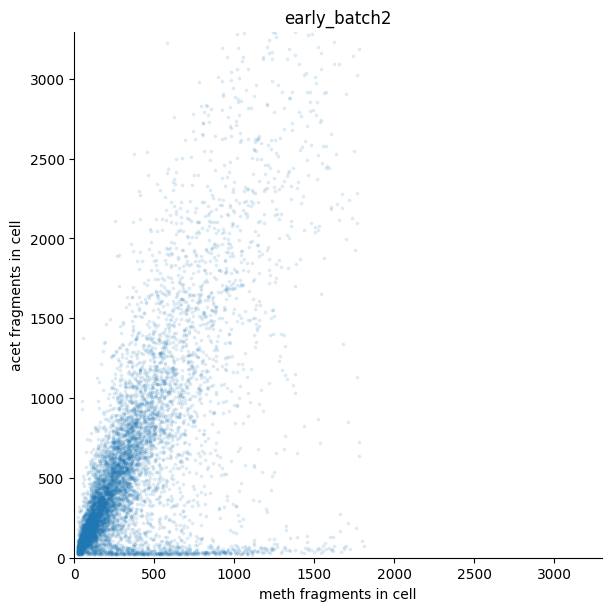

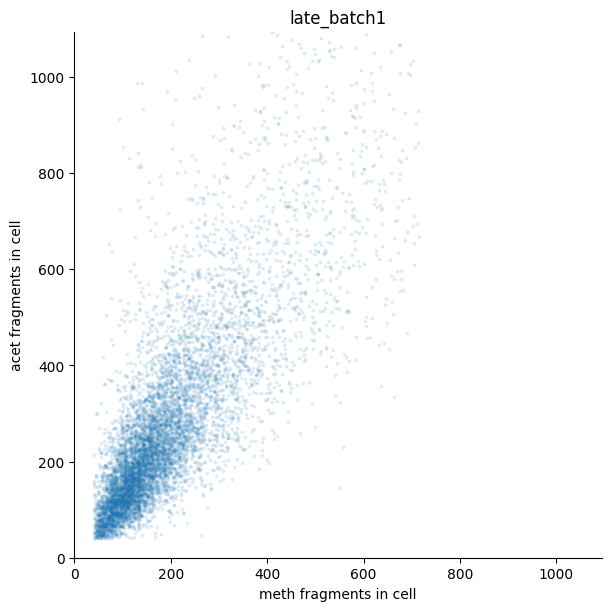

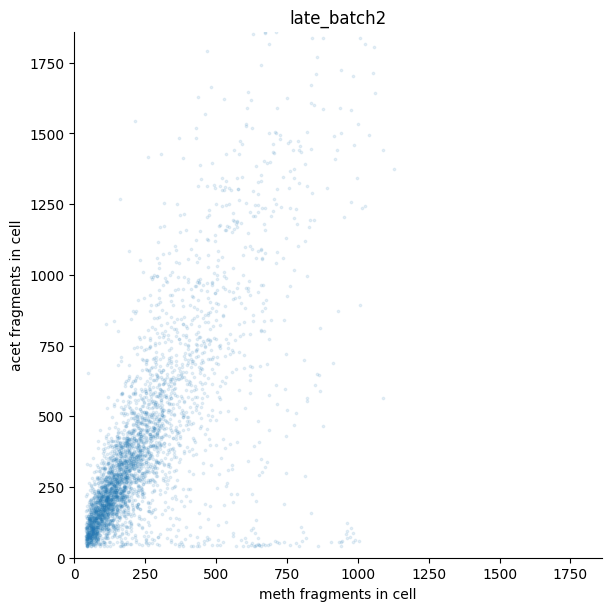

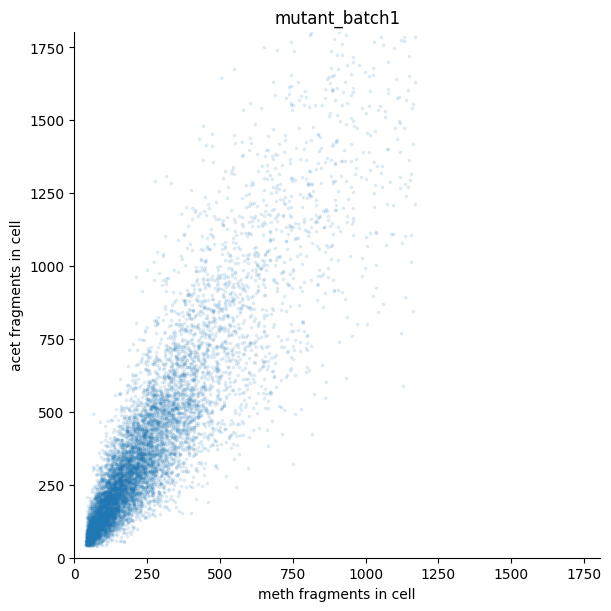

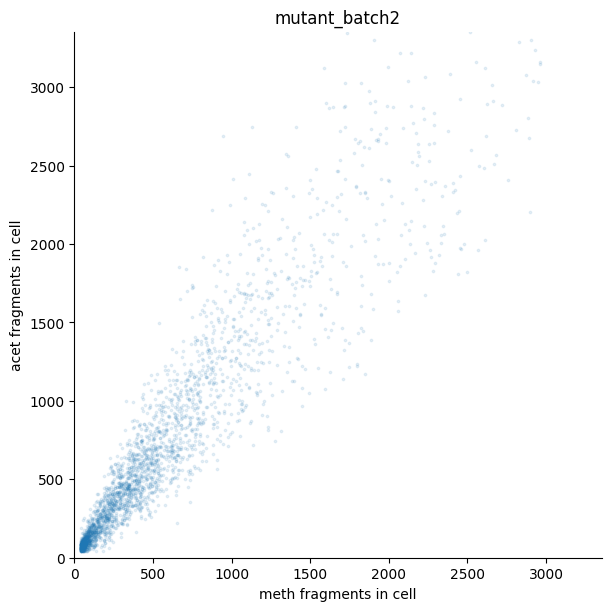

In [25]:
uq = np.unique(adata.obs['identity'])
scit.set_defaults(figsize=(6,6))

for u in uq:
    _adata = adata[adata.obs['identity'] == u].copy()
    Xm = lc_meth.transform(_adata).sum(axis=1).A1
    Xa = lc_acet.transform(_adata).sum(axis=1).A1
    i = np.max(np.c_[Xm,Xa])
    f=scit.pl.int.scatter(np.c_[Xm,Xa],title=u,xminmax=(0,i),yminmax=(0,i),alpha=0.1,xlabel='meth fragments in cell',ylabel='acet fragments in cell',show=False)
    f.savefig(f'private/newest/fragmentcorr/{u}.png')